In [ ]:
import marimo as mo

# The GPU Memory Equation: Where Every Byte Goes

**Workshop Section 1** (20 min) | LLM Inference at Scale

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/workshop/demos/demo_b_memory_equation.ipynb)
[![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.marimo.io/github/harshuljain13/llm-inference-at-scale/blob/master/workshop/demos/demo_b_memory_equation.ipynb)

**Goal:** Derive model memory from 3 anchor values, understand KV cache growth, and calculate how many users fit on your GPU.

Repo: [github.com/harshuljain13/llm-inference-at-scale](https://github.com/harshuljain13/llm-inference-at-scale)


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


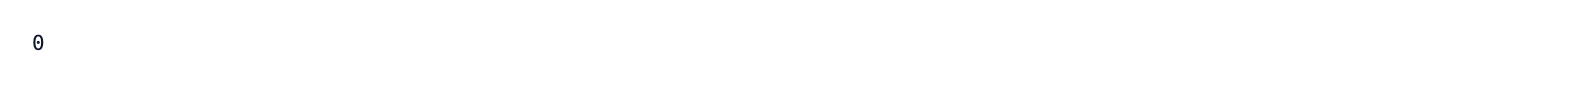

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'transformers', 'matplotlib'])

## The Three Anchor Values

Every transformer's memory footprint is determined by just three numbers:

| Symbol | Meaning | Mistral-7B |
|--------|---------|-------------|
| **d** | Hidden dimension | 4096 |
| **L** | Number of layers | 32 |
| **P** | Total parameters | 7.3B |

From these, we derive everything: weight memory, KV cache per token, and max concurrent users.

In [ ]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained('mistralai/Mistral-7B-v0.1')

d = config.hidden_size
L = config.num_hidden_layers
n_heads = config.num_attention_heads
n_kv_heads = config.num_key_value_heads
head_dim = d // n_heads
intermediate = config.intermediate_size

print(f'Hidden dim (d): {d}')
print(f'Layers (L): {L}')
print(f'Attention heads: {n_heads}, KV heads: {n_kv_heads}')
print(f'Head dim: {head_dim}')
print(f'MLP intermediate: {intermediate}')

Hidden dim (d): 4096
Layers (L): 32
Attention heads: 32, KV heads: 8
Head dim: 128
MLP intermediate: 14336


## Deriving Model Size

In FP16 (2 bytes per parameter):

$$\text{Model Memory} = P \times 2 \text{ bytes}$$

For 7.3B params: **~14.6 GB** just for weights.

But where do those parameters live? Let's break it down layer by layer.

In [ ]:
bytes_per_param = 2  # FP16

# Per-layer attention: Q, K, V, O projections
attn_params = 4 * d * (n_kv_heads * head_dim) + 4 * d * d  # simplified

# Correct: Q = d*d, K = d*kv_d, V = d*kv_d, O = d*d
kv_d = n_kv_heads * head_dim

attn_params = d*d + d*kv_d + d*kv_d + d*d  # Q + K + V + O
attn_bytes = attn_params * bytes_per_param

# Per-layer MLP: gate, up, down (Llama uses SwiGLU: 3 matrices)
mlp_params = 3 * d * intermediate
mlp_bytes = mlp_params * bytes_per_param

# Total
layer_bytes = attn_bytes + mlp_bytes
total_bytes = layer_bytes * L

print(f'Per layer attention: {attn_bytes/1e6:.1f} MB ({attn_params/1e6:.1f}M params)')
print(f'Per layer MLP:       {mlp_bytes/1e6:.1f} MB ({mlp_params/1e6:.1f}M params)')
print(f'Per layer total:     {layer_bytes/1e6:.1f} MB')
print(f'All {L} layers:      {total_bytes/1e9:.2f} GB')
print(f'\n+ Embeddings & LM head: ~{(8.03e9*2 - total_bytes)/1e9:.2f} GB')
print(f'= Total model memory:  ~{7.3e9*2/1e9:.1f} GB (FP16)')

Per layer attention: 83.9 MB (41.9M params)
Per layer MLP:       352.3 MB (176.2M params)
Per layer total:     436.2 MB
All 32 layers:      13.96 GB

+ Embeddings & LM head: ~2.10 GB
= Total model memory:  ~14.6 GB (FP16)


## KV Cache: The Variable Cost

Each token stored in KV cache costs:

$$\text{KV per token} = 2 \times L \times n_{kv} \times d_h \times 2 \text{ bytes}$$

- Factor of 2: one K vector + one V vector
- $n_{kv}$: number of KV heads (8 for GQA in Llama 3.1)
- $d_h$: head dimension (128)
- Final 2: FP16 bytes

For Mistral-7B: $2 \times 32 \times 8 \times 128 \times 2 = $ **128 KB per token**

This is the cost that scales with context length AND concurrent users.

KV cache per token: 128 KB


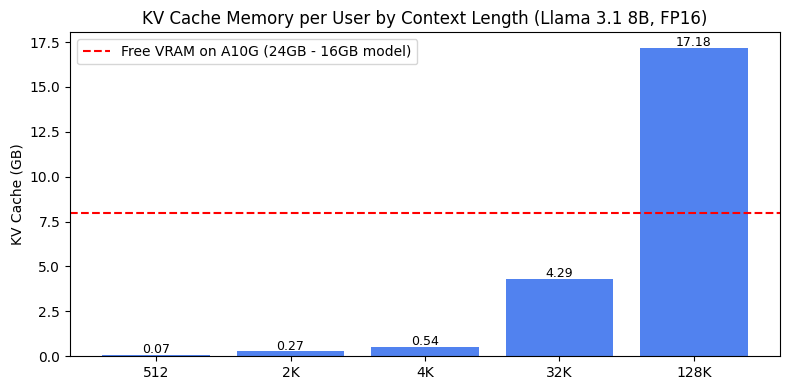

In [ ]:
import matplotlib.pyplot as plt

# mathematical formula
kv_per_token = 2 * L * n_kv_heads * head_dim * bytes_per_param

print(f'KV cache per token: {kv_per_token / 1024:.0f} KB')

ctx_lengths = [512, 2048, 4096, 32768, 131072]

_kv_gb = [kv_per_token * s / 1000000000.0 for s in ctx_lengths]

plt.figure(figsize=(8, 4))
bars = plt.bar([f'{s // 1024}K' if s >= 1024 else str(s) for s in ctx_lengths], _kv_gb, color='#2563eb', alpha=0.8)
plt.ylabel('KV Cache (GB)')
plt.title('KV Cache Memory per User by Context Length (Llama 3.1 8B, FP16)')
plt.axhline(y=24 - 16, color='red', linestyle='--', label='Free VRAM on A10G (24GB - 16GB model)')
plt.legend()
for bar, val in zip(bars, _kv_gb):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### How KV Cache Scales with context and users both

131 KB per token sounds small. Multiply by context length and concurrent users:

In [ ]:
# === PARAMETERS (change these to explore) ===
CONTEXT_LENGTHS = [1024, 2048, 4096, 8192, 16384]
USER_COUNTS = [1, 10, 40, 80, 160]

print(f'KV Cache Memory (GB) for Mistral-7B FP16:')
# Print the scaling table
print(f'')
header = f"{'Context':>8}" + ''.join((f'{n:>8} users' for n in USER_COUNTS))
print(header)
print('-' * len(header))
for ctx in CONTEXT_LENGTHS:
    row = f'{ctx:>8}'
    for _n_users in USER_COUNTS:
        _kv_gb = kv_per_token * ctx * _n_users / 1000000000.0
        row += f'{_kv_gb:>10.1f}'
    print(row)
print(f'')
print(f'80 users at 4K context = {kv_per_token * 4096 * 80 / 1000000000.0:.1f} GB of KV cache alone.')
print(f'Model weights are another 14.5 GB on top of this.')

KV Cache Memory (GB) for Mistral-7B FP16:

 Context       1 users      10 users      40 users      80 users     160 users
------------------------------------------------------------------------------
    1024       0.1       1.3       5.4      10.7      21.5
    2048       0.3       2.7      10.7      21.5      42.9
    4096       0.5       5.4      21.5      42.9      85.9
    8192       1.1      10.7      42.9      85.9     171.8
   16384       2.1      21.5      85.9     171.8     343.6

80 users at 4K context = 42.9 GB of KV cache alone.
Model weights are another 14.5 GB on top of this.


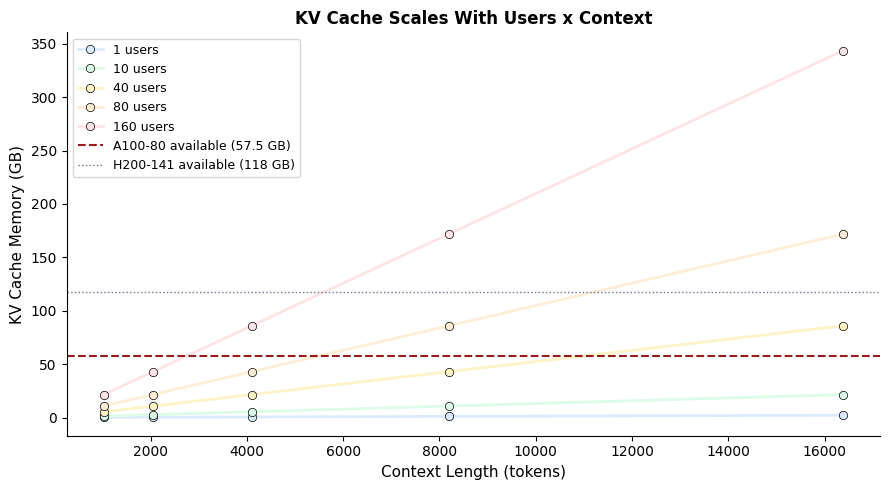

Lines above the dashed red = OOM on A100-80.


In [ ]:
# Visualize: KV cache growth
fig_kv, ax_kv = plt.subplots(figsize=(9, 5))
plot_colors = ['#dbeafe', '#dcfce7', '#fef3c7', '#ffedd5', '#ffe4e6']
for ui, _n_users in enumerate(USER_COUNTS):
    kv_values = [kv_per_token * ctx * _n_users / 1000000000.0 for ctx in CONTEXT_LENGTHS]
    ax_kv.plot(CONTEXT_LENGTHS, kv_values, 'o-', color=plot_colors[ui], linewidth=2, markersize=6, label=f'{_n_users} users', markeredgecolor='#000', markeredgewidth=0.5)
ax_kv.axhline(y=57.5, color='#991b1b', linestyle='--', linewidth=1.5, label='A100-80 available (57.5 GB)')
ax_kv.axhline(y=118, color='#64748b', linestyle=':', linewidth=1, label='H200-141 available (118 GB)')
ax_kv.set_xlabel('Context Length (tokens)', fontsize=11)
ax_kv.set_ylabel('KV Cache Memory (GB)', fontsize=11)
# GPU available memory lines
ax_kv.set_title('KV Cache Scales With Users x Context', fontsize=12, fontweight='bold')
ax_kv.legend(fontsize=9, loc='upper left')
ax_kv.spines['top'].set_visible(False)
ax_kv.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print(f'Lines above the dashed red = OOM on A100-80.')

## Key Takeaway

| Component | Type | Scales With |
|-----------|------|-------------|
| Model weights | **Fixed** | Parameters |
| KV cache | **Variable** | Users x Context Length |

**Weights determine which GPU you need. KV cache is the variable cost that determines
how many users you can serve and how much it costs per token.**

| What | Number | Impact |
|------|--------|--------|
| KV per token | 131 KB | Fixed by model architecture |
| 80 users at 4K | 42 GB | Fills most of A100-80 |
| 80 users at 16K | 168 GB | Exceeds any single GPU |
| Best $/M tokens | H200 | More VRAM = better amortization |

**To serve more users:** reduce KV cache (quantize, evict, compress) or get more VRAM.
That's what the rest of this workshop teaches.

This is why every optimization in the next sections (quantization, GQA, paged attention, prefix caching) targets either reducing the fixed cost or compressing the variable cost.

---
*Next: Section 2 -- Why Is Decode So Slow? (The Roofline Model)*